# RTT Prediction Using Network Metadata

This notebook predicts average RTT between network peers using geographic, routing, and metadata-based features.  
A node-disjoint train/test split is used so that test peers are never observed during training.

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Node-Disjoint Train/Test Split

Instead of randomly splitting rows, nodes are assigned to either the training or test partition.  
Only pairs where both endpoints belong to the same partition are kept. This prevents the same IP address from appearing in both training and testing data.


In [2]:
N_LANDMARKS = 150
TEST_FRACTION = 0.30
SPLIT_SALT = "lat-est-v1"


def bucket(addr):
    digest = hashlib.blake2b(
        f"{SPLIT_SALT}:{addr}".encode(),
        digest_size=8
    ).digest()
    return int.from_bytes(digest, "big") % 10000


def assign_roles(df):
    dual = set(df["src_addr"]) & set(df["dst_addr"])

    ranked = (
        pl.concat([
            df.select(pl.col("src_addr").alias("addr")),
            df.select(pl.col("dst_addr").alias("addr"))
        ])
        .filter(pl.col("addr").is_in(dual))
        .group_by("addr")
        .len()
        .with_columns(
            tie=pl.col("addr").map_elements(
                bucket,
                return_dtype=pl.Int64
            )
        )
        .sort(["len", "tie"], descending=[True, False])
    )

    landmarks = set(ranked.head(N_LANDMARKS)["addr"])
    peers = dual - landmarks

    test_peers = {
        p for p in peers
        if bucket(p) < TEST_FRACTION * 10000
    }

    train_peers = peers - test_peers

    return landmarks, train_peers, test_peers

## Dataset Loading

The dataset is loaded from a local parquet file.  
For reproducibility, update `DATA_PATH` to point to the location of `df_original.parquet`.


In [4]:
DATA_PATH = Path("data/df_original.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Place df_original.parquet inside the data/ folder "
        "or update DATA_PATH to your local path."
    )

pdf = pd.read_parquet(DATA_PATH)
df_polars = pl.from_pandas(pdf)

landmarks, train_peers, test_peers = assign_roles(df_polars)

train_df = pdf[
    pdf["src_addr"].isin(train_peers) &
    pdf["dst_addr"].isin(train_peers)
].copy()

test_df = pdf[
    pdf["src_addr"].isin(test_peers) &
    pdf["dst_addr"].isin(test_peers)
].copy()

print("Full dataset:", pdf.shape)
print("Train set:", train_df.shape)
print("Test set:", test_df.shape)
print("Train peers:", len(train_peers))
print("Test peers:", len(test_peers))
print("Landmarks:", len(landmarks))
print("Test row fraction:", test_df.shape[0] / (train_df.shape[0] + test_df.shape[0]))

Full dataset: (1116767, 41)
Train set: (322372, 41)
Test set: (62078, 41)
Train peers: 586
Test peers: 258
Landmarks: 150
Test row fraction: 0.16147223306021588


## Exploratory Data Analysis

This section summarizes the full RTT dataset and visualizes the distribution of the target variable and key network-related features.

Dataset shape:
(1116767, 41)

Columns:
['timestamp', 'src_addr', 'dst_addr', 'sent', 'rcvd', 'dup', 'min', 'max', 'avg', 'src_continent', 'src_country', 'src_longitude', 'src_latitude', 'src_asn', 'src_conn_type', 'src_provider', 'src_is_mobile', 'src_is_cloud_provider', 'src_is_proxy', 'src_is_vpn', 'src_is_tor', 'src_is_tor_exit', 'dst_continent', 'dst_country', 'dst_longitude', 'dst_latitude', 'dst_asn', 'dst_conn_type', 'dst_provider', 'dst_is_mobile', 'dst_is_cloud_provider', 'dst_is_proxy', 'dst_is_vpn', 'dst_is_tor', 'dst_is_tor_exit', 'hop_count', 'distance_km', 'src_prefix_8', 'src_prefix_16', 'dst_prefix_8', 'dst_prefix_16']

Missing values:
src_continent      19717
dst_continent      19516
hop_count           3648
src_country         1389
dst_country         1083
dst_provider         814
src_provider         308
src_asn              249
src_conn_type        249
distance_km          248
src_is_tor_exit      248
src_is_mobile        248
src_is_proxy         248
src_is_tor     

,sent,rcvd,dup,min,max,avg,src_longitude,src_latitude,src_asn,dst_longitude,dst_latitude,dst_asn,hop_count,distance_km
count,1.116767e+06,1.116767e+06,1.116767e+06,1.116767e+06,1.116767e+06,1.116767e+06,1.116519e+06,1.116519e+06,1.116518e+06,1.116767e+06,1.116767e+06,1.116766e+06,1.113119e+06,1.116519e+06
mean,2.997678e+00,2.992609e+00,1.168641e-02,1.300253e+02,1.316607e+02,1.307174e+02,6.662239e+00,3.534433e+01,8.156223e+04,6.538874e+00,3.473414e+01,8.621833e+04,2.487146e+01,6.403188e+03
std,2.008050e-01,2.207345e-01,7.494133e-01,9.300278e+01,9.434062e+01,9.327979e+01,6.608989e+01,2.494558e+01,9.741674e+04,6.712891e+01,2.507188e+01,9.937916e+04,5.247144e+01,4.753874e+03
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.034000e-02,1.920633e-02,-1.597755e+02,-5.451088e+01,4.000000e+00,-1.231367e+02,-5.034085e+01,1.600000e+01,1.000000e+00,0.000000e+00
25%,3.000000e+00,3.000000e+00,0.000000e+00,4.020587e+01,4.130960e+01,4.076241e+01,-3.657250e+00,3.362270e+01,1.627600e+04,-4.483280e+00,3.272538e+01,1.789300e+04,1.000000e+01,1.513945e+03
50%,3.000000e+00,3.000000e+00,0.000000e+00,1.245524e+02,1.260413e+02,1.252450e+02,8.684080e+00,4.574914e+01,3.964200e+04,8.684080e+00,4.507051e+01,4.220700e+04,1.300000e+01,6.698981e+03
75%,3.000000e+00,3.000000e+00,0.000000e+00,1.935865e+02,1.953751e+02,1.943991e+02,2.610253e+01,5.085052e+01,1.392250e+05,2.804369e+01,5.027969e+01,1.496970e+05,1.600000e+01,9.571421e+03
max,1.000000e+01,1.000000e+01,1.650000e+02,9.917884e+02,2.315299e+03,1.066400e+03,1.791942e+02,6.996879e+01,4.021640e+05,1.791942e+02,6.728274e+01,4.016120e+05,2.550000e+02,1.998166e+04


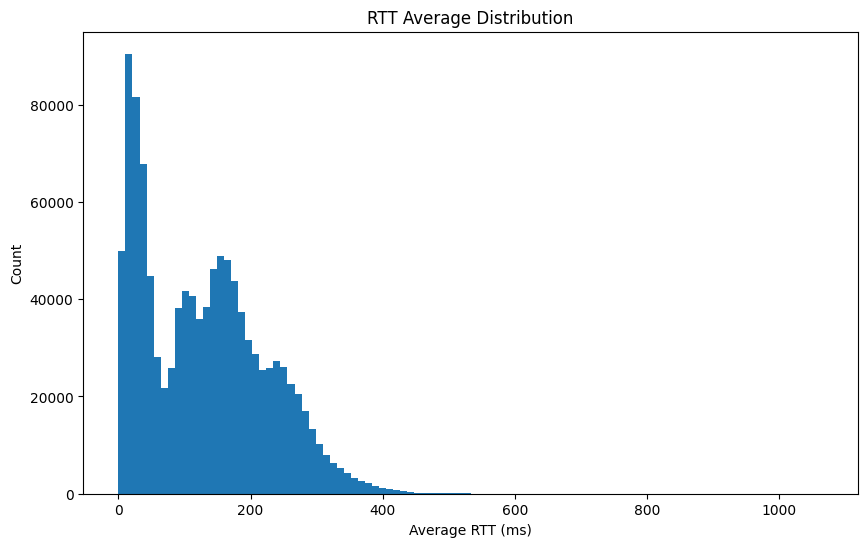

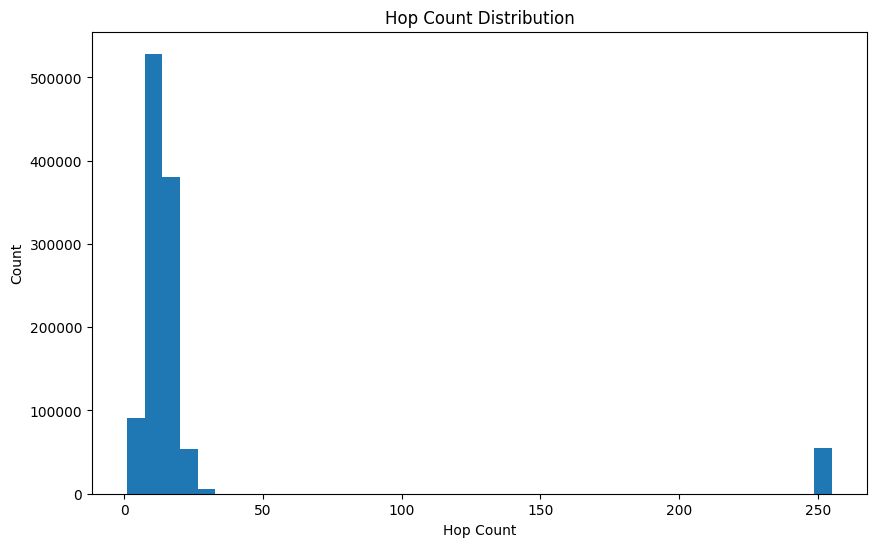

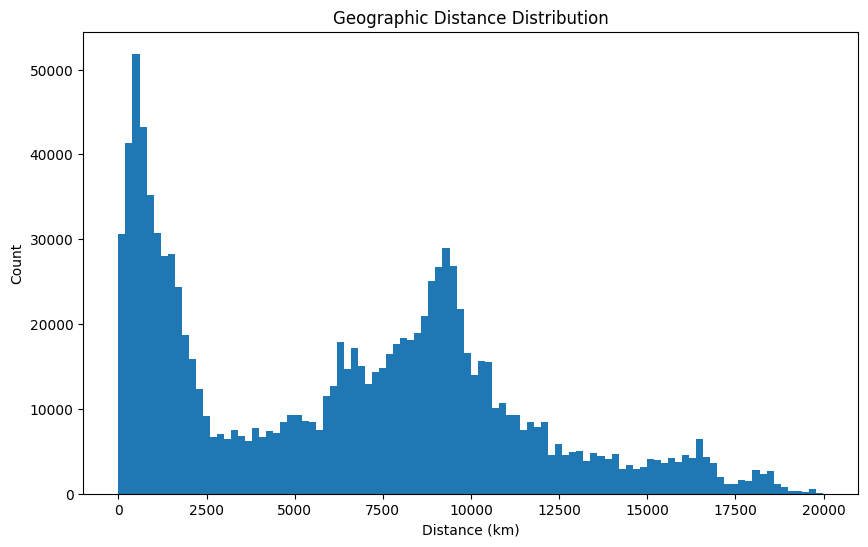

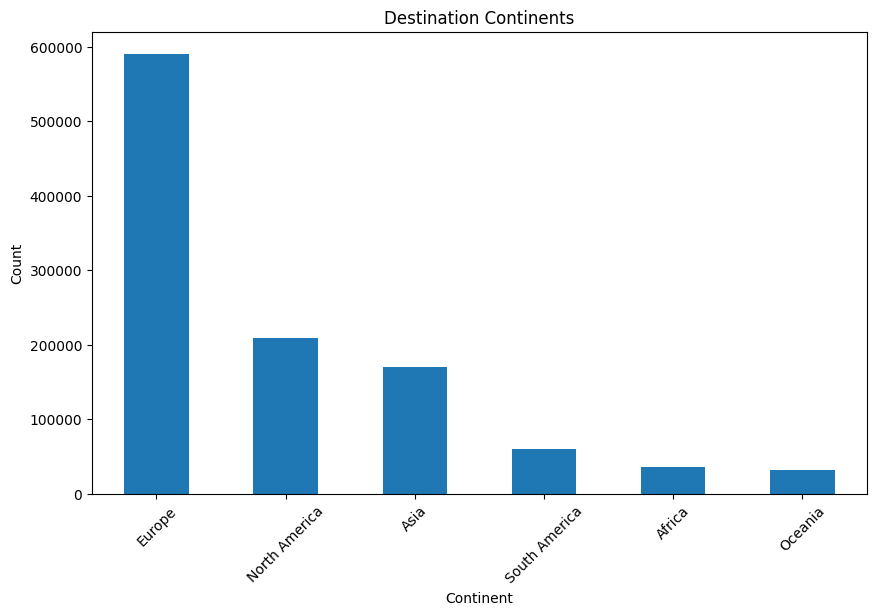


Unique destination ASNs:
847

Top destination ASNs:
dst_asn
16552.0     28899
20473.0     19332
202422.0    16305
31713.0     13386
48503.0     13039
14061.0      8965
36236.0      8618
208398.0     8082
16276.0      7660
199610.0     6564
55002.0      6321
680.0        6249
197556.0     5619
21299.0      5605
14907.0      5554
37468.0      5413
58057.0      5297
42473.0      5240
3320.0       4949
4826.0       4764
Name: count, dtype: int64

Top destination providers:
dst_provider
digicert.com        28899
constant.com        19332
gcore.lu            17436
pccwglobal.com      15607
tele2.kz            13039
beeline.kz          11224
misaka.email        10183
digitalocean.com     8965
netactuate.com       8618
twnic.net            8615
tele.tech            8082
ovh.net              7660
criteo.com           6855
apjii.or.id          6728
nitrado.net          6564
anexia.at            6448
f5.com               6321
securebit.ch         6321
dfn.de               6249
wikimedia.org     

,avg,min,max,hop_count,distance_km,sent,rcvd,dup
avg,1.000000,0.998103,0.995398,0.098654,0.873243,-0.017014,-0.023244,0.003123
min,0.998103,1.000000,0.988005,0.098774,0.875847,-0.016802,-0.022917,0.002995
max,0.995398,0.988005,1.000000,0.097640,0.863329,-0.016101,-0.022423,0.003227
hop_count,0.098654,0.098774,0.097640,1.000000,0.096366,-0.005075,-0.008586,-0.000659
distance_km,0.873243,0.875847,0.863329,0.096366,1.000000,-0.020343,-0.019305,0.000354
sent,-0.017014,-0.016802,-0.016101,-0.005075,-0.020343,1.000000,0.921387,-0.000183
rcvd,-0.023244,-0.022917,-0.022423,-0.008586,-0.019305,0.921387,1.000000,-0.000192
dup,0.003123,0.002995,0.003227,-0.000659,0.000354,-0.000183,-0.000192,1.000000


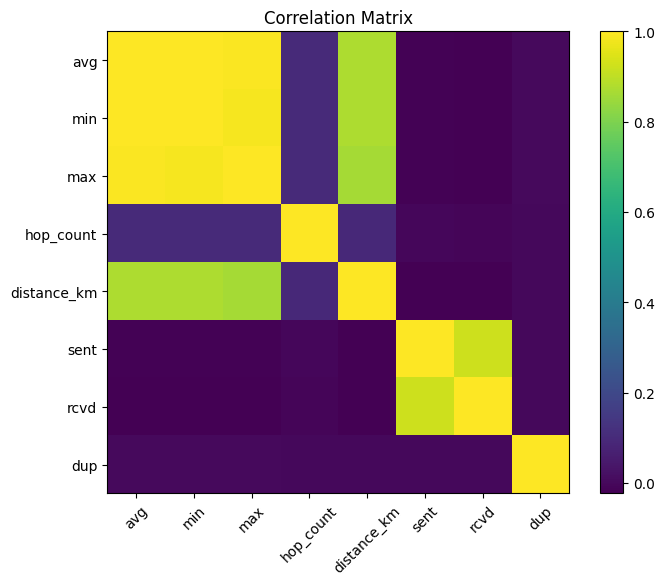

In [5]:
df = pdf.copy()

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(15))

numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("\nNumerical summary:")
display(df[numeric_cols].describe())

plt.figure(figsize=(10, 6))
plt.hist(df["avg"].dropna(), bins=100)
plt.title("RTT Average Distribution")
plt.xlabel("Average RTT (ms)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["hop_count"].dropna(), bins=40)
plt.title("Hop Count Distribution")
plt.xlabel("Hop Count")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["distance_km"].dropna(), bins=100)
plt.title("Geographic Distance Distribution")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
df["dst_continent"].value_counts().plot(kind="bar")
plt.title("Destination Continents")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print("\nUnique destination ASNs:")
print(df["dst_asn"].nunique())

print("\nTop destination ASNs:")
print(df["dst_asn"].value_counts().head(20))

print("\nTop destination providers:")
print(df["dst_provider"].value_counts().head(20))

security_cols = [
    "dst_is_vpn",
    "dst_is_proxy",
    "dst_is_tor",
    "dst_is_cloud_provider"
]

for col in security_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

corr_cols = [
    "avg",
    "min",
    "max",
    "hop_count",
    "distance_km",
    "sent",
    "rcvd",
    "dup"
]

corr_df = df[corr_cols].corr()

print("\nCorrelation matrix:")
display(corr_df)

plt.figure(figsize=(8, 6))
plt.imshow(corr_df)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

## Mutual Information Feature Analysis

Mutual Information is computed on the training set only, in order to estimate the predictive relevance of each feature without using information from the test set.

,Feature,MI Score
0,distance_km,1.618592e+00
20,src_prefix_16,4.505032e-01
22,dst_prefix_16,4.471992e-01
8,src_provider,4.122571e-01
9,dst_provider,4.108050e-01
7,dst_country,3.690014e-01
6,src_country,3.660354e-01
2,src_asn,3.144129e-01
3,dst_asn,3.136777e-01
19,src_prefix_8,2.286311e-01


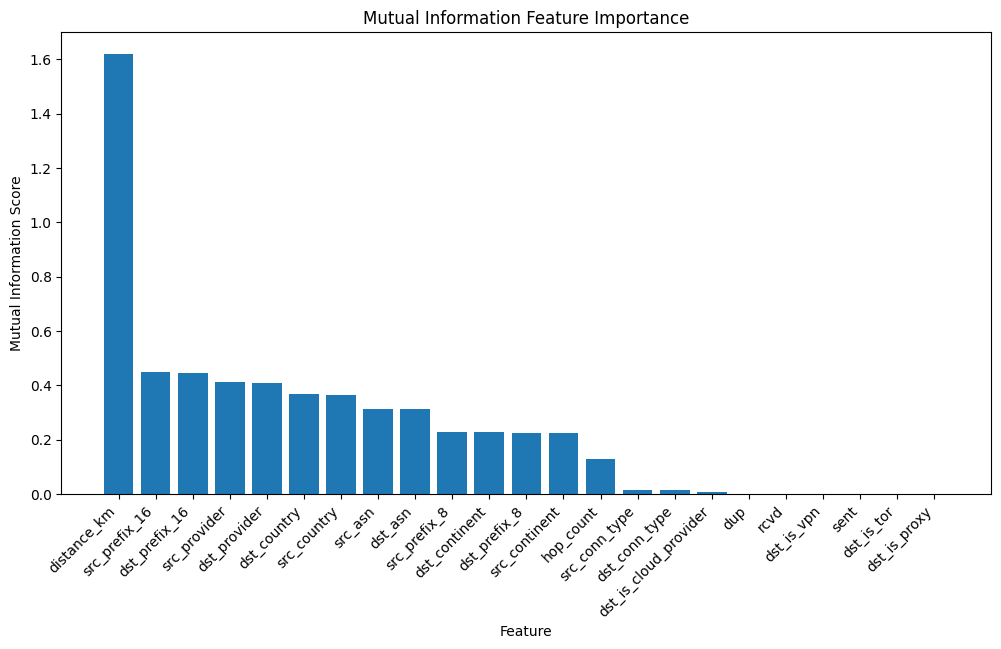

In [6]:
df_fi = train_df.copy()

target = "avg"

features = [
    "distance_km",
    "hop_count",
    "src_asn",
    "dst_asn",
    "src_continent",
    "dst_continent",
    "src_country",
    "dst_country",
    "src_provider",
    "dst_provider",
    "sent",
    "rcvd",
    "dup",
    "src_conn_type",
    "dst_conn_type",
    "dst_is_vpn",
    "dst_is_cloud_provider",
    "dst_is_proxy",
    "dst_is_tor",
    "src_prefix_8",
    "src_prefix_16",
    "dst_prefix_8",
    "dst_prefix_16"
]

features = [f for f in features if f in df_fi.columns]

df_fi = df_fi[features + [target]].copy()
df_fi = df_fi[df_fi[target].notna()]

for col in features:
    if df_fi[col].dtype == "object":
        df_fi[col] = df_fi[col].fillna("unknown")
        le = LabelEncoder()
        df_fi[col] = le.fit_transform(df_fi[col].astype(str))
    else:
        df_fi[col] = df_fi[col].fillna(df_fi[col].median())

X_mi = df_fi[features]
y_mi = df_fi[target]

mi_scores = mutual_info_regression(
    X_mi,
    y_mi,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": features,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

display(mi_df)

plt.figure(figsize=(12, 6))
plt.bar(mi_df["Feature"], mi_df["MI Score"])
plt.title("Mutual Information Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Mutual Information Score")
plt.xticks(rotation=45, ha="right")
plt.show()

## Random Forest Baseline Model

A Random Forest Regressor is trained using the node-disjoint training set and evaluated on unseen test peers.  
Categorical features are label-encoded and missing values are imputed using statistics from the training set.

Train size: (322372, 14)
Test size: (62078, 14)

MODEL PERFORMANCE
-----------------
MAE  : 24.942 ms
RMSE : 39.820 ms
R²   : 0.8269

Random Forest Feature Importance:


,Feature,Importance
0,distance_km,0.829708
4,src_continent,0.038362
5,dst_continent,0.037668
6,src_country,0.015924
7,dst_country,0.015880
1,hop_count,0.011721
10,src_prefix_16,0.009669
11,dst_prefix_16,0.009115
9,dst_provider,0.006714
3,dst_asn,0.006520


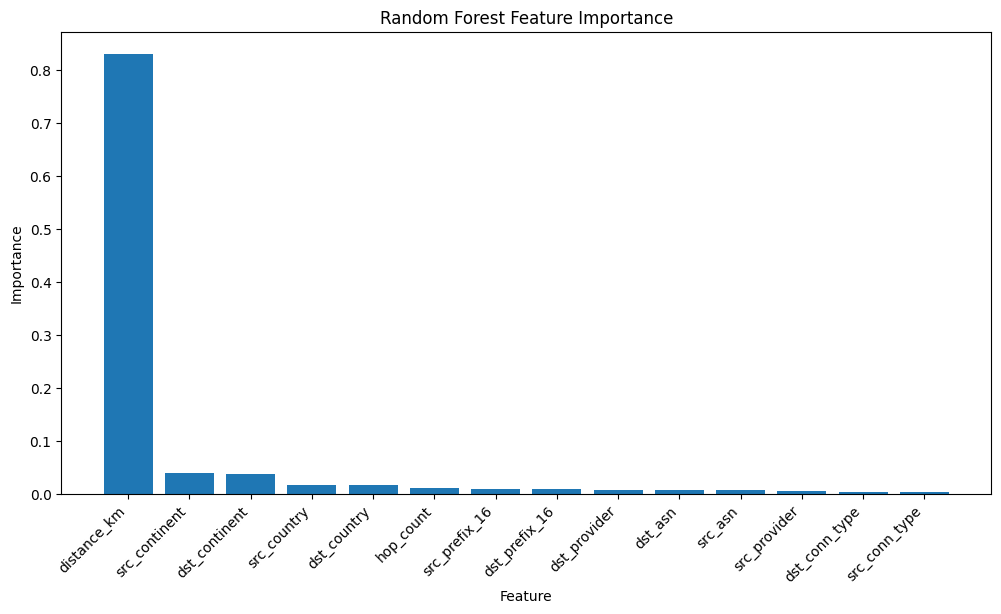

,Actual RTT,Predicted RTT,Absolute Error
0,39.512068,41.627123,2.115054
1,246.011939,265.231720,19.219781
2,14.535816,20.468801,5.932984
3,92.743060,156.901150,64.158090
4,105.479054,108.353019,2.873965
5,84.348080,142.832100,58.484020
6,24.709315,18.563112,6.146204
7,156.140367,154.964673,1.175693
8,80.505519,88.231072,7.725553
9,61.720975,74.692701,12.971726


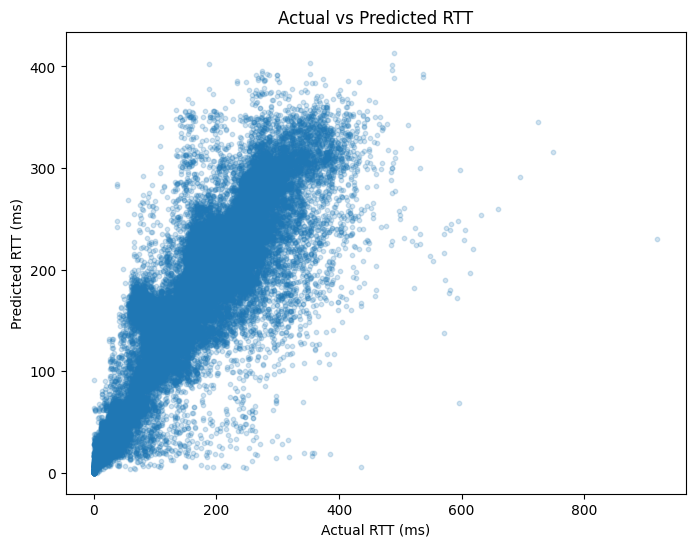

In [7]:
target = "avg"

features = [
    "distance_km",
    "hop_count",
    "src_asn",
    "dst_asn",
    "src_continent",
    "dst_continent",
    "src_country",
    "dst_country",
    "src_provider",
    "dst_provider",
    "src_prefix_16",
    "dst_prefix_16",
    "src_conn_type",
    "dst_conn_type"
]

features = [f for f in features if f in train_df.columns]

train_model = train_df[features + [target]].copy()
test_model = test_df[features + [target]].copy()

train_model = train_model[train_model[target].notna()]
test_model = test_model[test_model[target].notna()]

for col in features:
    if train_model[col].dtype == "object":
        train_model[col] = train_model[col].fillna("unknown")
        test_model[col] = test_model[col].fillna("unknown")

        le = LabelEncoder()
        le.fit(train_model[col].astype(str))

        train_model[col] = le.transform(train_model[col].astype(str))

        test_model[col] = test_model[col].astype(str)
        test_model[col] = test_model[col].where(
            test_model[col].isin(le.classes_),
            "unknown"
        )

        if "unknown" not in le.classes_:
            le.classes_ = np.append(le.classes_, "unknown")

        test_model[col] = le.transform(test_model[col])

    else:
        median_value = train_model[col].median()
        train_model[col] = train_model[col].fillna(median_value)
        test_model[col] = test_model[col].fillna(median_value)

bool_cols = train_model.select_dtypes(include=["bool"]).columns

for col in bool_cols:
    train_model[col] = train_model[col].astype(int)
    test_model[col] = test_model[col].astype(int)

X_train = train_model[features]
y_train = train_model[target]

X_test = test_model[features]
y_test = test_model[target]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE")
print("-----------------")
print(f"MAE  : {mae:.3f} ms")
print(f"RMSE : {rmse:.3f} ms")
print(f"R²   : {r2:.4f}")

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
display(importance_df)

plt.figure(figsize=(12, 6))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

comparison_df = pd.DataFrame({
    "Actual RTT": y_test.values,
    "Predicted RTT": y_pred,
    "Absolute Error": np.abs(y_test.values - y_pred)
})

display(comparison_df.head(20))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.2, s=10)
plt.xlabel("Actual RTT (ms)")
plt.ylabel("Predicted RTT (ms)")
plt.title("Actual vs Predicted RTT")
plt.show()

## Random Forest Hyperparameter Tuning

Several Random Forest configurations are evaluated by varying the number of trees, tree depth, and leaf size. The objective is to determine whether a more complex ensemble can improve prediction accuracy on unseen peers.


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

rf_results = []

configs = [
    (100, 20, 5),
    (200, 20, 5),
    (300, 20, 5),

    (100, 25, 5),
    (200, 25, 5),
    (300, 25, 5),

    (100, None, 5),
    (200, None, 5),

    (100, 20, 2),
    (200, 20, 2),

    (100, 30, 1),
    (200, 30, 1),
]

for n_estimators, max_depth, min_samples_leaf in configs:

    print(
        f"Running RF: trees={n_estimators}, "
        f"depth={max_depth}, "
        f"leaf={min_samples_leaf}"
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rf_results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

rf_results_df = pd.DataFrame(rf_results)
rf_results_df = rf_results_df.sort_values(
    by="R2",
    ascending=False
)

display(rf_results_df)

print("\nBest Random Forest configuration:")
display(rf_results_df.head(1))

Running RF: trees=100, depth=20, leaf=5
Running RF: trees=200, depth=20, leaf=5
Running RF: trees=300, depth=20, leaf=5
Running RF: trees=100, depth=25, leaf=5
Running RF: trees=200, depth=25, leaf=5
Running RF: trees=300, depth=25, leaf=5
Running RF: trees=100, depth=None, leaf=5
Running RF: trees=200, depth=None, leaf=5
Running RF: trees=100, depth=20, leaf=2
Running RF: trees=200, depth=20, leaf=2
Running RF: trees=100, depth=30, leaf=1
Running RF: trees=200, depth=30, leaf=1


,n_estimators,max_depth,min_samples_leaf,R2,MAE,RMSE
5,300,25.0,5,0.829154,24.975415,39.556093
2,300,20.0,5,0.829125,24.827289,39.559490
4,200,25.0,5,0.828728,24.989836,39.605474
1,200,20.0,5,0.828659,24.842725,39.613406
7,200,NaN,5,0.828453,25.031099,39.637212
3,100,25.0,5,0.827221,25.051568,39.779310
6,100,NaN,5,0.827002,25.101727,39.804433
0,100,20.0,5,0.826871,24.942402,39.819545
9,200,20.0,2,0.822823,25.720517,40.282427
8,100,20.0,2,0.820508,25.856791,40.544715



Best Random Forest configuration:


,n_estimators,max_depth,min_samples_leaf,R2,MAE,RMSE
5,300,25.0,5,0.829154,24.975415,39.556093


## XGBoost Model Evaluation

XGBoost is evaluated as a gradient boosting alternative to Random Forest. Multiple configurations are tested by varying tree depth, learning rate, and the number of boosting rounds.

In [9]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

xgb_results = []

configs = [
    (300, 6, 0.05),
    (500, 6, 0.05),

    (300, 8, 0.05),
    (500, 8, 0.05),

    (300, 10, 0.05),

    (300, 6, 0.10),
    (500, 6, 0.10),

    (300, 8, 0.10),
    (500, 8, 0.10),
]

for n_estimators, max_depth, learning_rate in configs:

    print(
        f"Running XGB: trees={n_estimators}, "
        f"depth={max_depth}, "
        f"lr={learning_rate}"
    )

    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    xgb_results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

xgb_results_df = pd.DataFrame(xgb_results)
xgb_results_df = xgb_results_df.sort_values(
    by="R2",
    ascending=False
)

display(xgb_results_df)

print("\nBest XGBoost configuration:")
display(xgb_results_df.head(1))

Running XGB: trees=300, depth=6, lr=0.05
Running XGB: trees=500, depth=6, lr=0.05
Running XGB: trees=300, depth=8, lr=0.05
Running XGB: trees=500, depth=8, lr=0.05
Running XGB: trees=300, depth=10, lr=0.05
Running XGB: trees=300, depth=6, lr=0.1
Running XGB: trees=500, depth=6, lr=0.1
Running XGB: trees=300, depth=8, lr=0.1
Running XGB: trees=500, depth=8, lr=0.1


,n_estimators,max_depth,learning_rate,R2,MAE,RMSE
2,300,8,0.05,0.846776,25.020077,37.460610
4,300,10,0.05,0.845698,25.157619,37.592151
3,500,8,0.05,0.842614,25.482783,37.965960
8,500,8,0.10,0.841272,24.839288,38.127434
7,300,8,0.10,0.841194,24.877617,38.136902
0,300,6,0.05,0.839822,25.779747,38.301252
1,500,6,0.05,0.839124,25.851313,38.384644
5,300,6,0.10,0.836588,25.808363,38.685999
6,500,6,0.10,0.836497,25.403642,38.696719



Best XGBoost configuration:


,n_estimators,max_depth,learning_rate,R2,MAE,RMSE
2,300,8,0.05,0.846776,25.020077,37.46061


## LightGBM Model Evaluation

LightGBM is evaluated as a scalable gradient boosting framework designed for large tabular datasets. Different combinations of boosting rounds, leaves, and learning rates are tested.

In [10]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

lgbm_results = []

configs = [
    (300, 31, 0.05),
    (500, 31, 0.05),
    (800, 31, 0.05),

    (300, 63, 0.05),
    (500, 63, 0.05),

    (300, 127, 0.05),
    (500, 127, 0.05),

    (300, 31, 0.10),
    (500, 31, 0.10),

    (300, 63, 0.10),
    (500, 63, 0.10),
]

for n_estimators, num_leaves, learning_rate in configs:

    print(
        f"Running LGBM: trees={n_estimators}, "
        f"leaves={num_leaves}, "
        f"lr={learning_rate}"
    )

    model = LGBMRegressor(
        n_estimators=n_estimators,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    lgbm_results.append({
        "n_estimators": n_estimators,
        "num_leaves": num_leaves,
        "learning_rate": learning_rate,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

lgbm_results_df = pd.DataFrame(lgbm_results)
lgbm_results_df = lgbm_results_df.sort_values(
    by="R2",
    ascending=False
)

display(lgbm_results_df)

print("\nBest LightGBM configuration:")
display(lgbm_results_df.head(1))

Running LGBM: trees=300, leaves=31, lr=0.05
Running LGBM: trees=500, leaves=31, lr=0.05
Running LGBM: trees=800, leaves=31, lr=0.05
Running LGBM: trees=300, leaves=63, lr=0.05
Running LGBM: trees=500, leaves=63, lr=0.05
Running LGBM: trees=300, leaves=127, lr=0.05
Running LGBM: trees=500, leaves=127, lr=0.05
Running LGBM: trees=300, leaves=31, lr=0.1
Running LGBM: trees=500, leaves=31, lr=0.1
Running LGBM: trees=300, leaves=63, lr=0.1
Running LGBM: trees=500, leaves=63, lr=0.1


,n_estimators,num_leaves,learning_rate,R2,MAE,RMSE
6,500,127,0.05,0.850872,24.627622,36.956518
5,300,127,0.05,0.850705,24.705404,36.977245
8,500,31,0.10,0.849008,24.404327,37.186750
4,500,63,0.05,0.848286,24.931463,37.275531
2,800,31,0.05,0.848002,25.342458,37.310401
3,300,63,0.05,0.847690,24.942148,37.348695
0,300,31,0.05,0.847446,25.281883,37.378652
7,300,31,0.10,0.847373,24.910697,37.387598
9,300,63,0.10,0.846362,24.970127,37.511194
1,500,31,0.05,0.846221,25.540085,37.528396



Best LightGBM configuration:


,n_estimators,num_leaves,learning_rate,R2,MAE,RMSE
6,500,127,0.05,0.850872,24.627622,36.956518


In [11]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import numpy as np
import pandas as pd

# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Scale features
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# -----------------------------
# Train / validation split
# -----------------------------
full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4096,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=4096,
    shuffle=False
)

# -----------------------------
# MLP model
# -----------------------------
class MLPRegressorTorch(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


model = MLPRegressorTorch(
    input_dim=X_train.shape[1]
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# -----------------------------
# Training loop with early stopping
# -----------------------------
best_val_loss = np.inf
best_state = None
patience = 8
patience_counter = 0
max_epochs = 100

history = []

for epoch in range(1, max_epochs + 1):

    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = criterion(preds, yb)

            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(
        f"Epoch {epoch:03d} | "
        f"Train MSE: {train_loss:.3f} | "
        f"Val MSE: {val_loss:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# -----------------------------
# Load best model
# -----------------------------
model.load_state_dict(best_state)

# -----------------------------
# Evaluation on test set
# -----------------------------
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        preds = model(xb).cpu().numpy().ravel()

        all_preds.extend(preds)
        all_targets.extend(yb.numpy().ravel())

y_pred_torch = np.array(all_preds)
y_true_torch = np.array(all_targets)

torch_r2 = r2_score(y_true_torch, y_pred_torch)
torch_mae = mean_absolute_error(y_true_torch, y_pred_torch)
torch_rmse = np.sqrt(mean_squared_error(y_true_torch, y_pred_torch))

print("\nPYTORCH MLP PERFORMANCE")
print("-----------------------")
print(f"MAE  : {torch_mae:.3f} ms")
print(f"RMSE : {torch_rmse:.3f} ms")
print(f"R²   : {torch_r2:.4f}")

torch_results_df = pd.DataFrame([{
    "Model": "PyTorch MLP",
    "Architecture": "128-64",
    "R2": torch_r2,
    "MAE": torch_mae,
    "RMSE": torch_rmse
}])

display(torch_results_df)

Using device: cpu
Epoch 001 | Train MSE: 10581.555 | Val MSE: 2139.474
Epoch 002 | Train MSE: 1839.716 | Val MSE: 1554.530
Epoch 003 | Train MSE: 1626.299 | Val MSE: 1457.814
Epoch 004 | Train MSE: 1557.407 | Val MSE: 1400.273
Epoch 005 | Train MSE: 1521.146 | Val MSE: 1358.609
Epoch 006 | Train MSE: 1490.513 | Val MSE: 1324.599
Epoch 007 | Train MSE: 1461.455 | Val MSE: 1297.170
Epoch 008 | Train MSE: 1433.417 | Val MSE: 1270.096
Epoch 009 | Train MSE: 1417.816 | Val MSE: 1240.908
Epoch 010 | Train MSE: 1387.657 | Val MSE: 1209.672
Epoch 011 | Train MSE: 1359.126 | Val MSE: 1179.550
Epoch 012 | Train MSE: 1338.114 | Val MSE: 1152.420
Epoch 013 | Train MSE: 1312.547 | Val MSE: 1128.472
Epoch 014 | Train MSE: 1301.128 | Val MSE: 1114.394
Epoch 015 | Train MSE: 1289.959 | Val MSE: 1105.747
Epoch 016 | Train MSE: 1275.309 | Val MSE: 1090.190
Epoch 017 | Train MSE: 1264.770 | Val MSE: 1082.384
Epoch 018 | Train MSE: 1257.233 | Val MSE: 1069.049
Epoch 019 | Train MSE: 1252.040 | Val MSE: 10

,Model,Architecture,R2,MAE,RMSE
0,PyTorch MLP,128-64,0.797492,28.380587,43.065792
